# Netflix Content Type Prediction
This notebook builds a compact, reproducible machine learning workflow to predict whether a title is a Movie or TV Show using engineered Netflix metadata.

The flow is kept intentionally clear: load data, prepare features, train a model, evaluate performance, and summarize the results for reporting and resume writing.

In [23]:
import warnings
warnings.filterwarnings("ignore")

import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

In [24]:
db_path = os.path.join("..", "database", "netflix.db")
conn = sqlite3.connect(db_path)

ml_df = pd.read_sql("SELECT * FROM netflix_data", conn)

feature_cols = [
    "release_year",
    "duration_num",
    "num_genres",
    "cast_count",
    "title_word_count",
    "description_word_count",
    "content_age",
    "content_age_missing",
    "release_decade",
]
feature_cols = [col for col in feature_cols if col in ml_df.columns]

ml_df = ml_df.dropna(subset=["type"]).copy()
y = (ml_df["type"].str.lower() == "movie").astype(int)
X = ml_df[feature_cols].copy()

print("SQLite database connection established")
print(f"Database path: {db_path}")
print(f"Dataset shape: {ml_df.shape}")
print(f"Features available ({len(feature_cols)}): {feature_cols}")
print("Target distribution:")
print(y.value_counts())

SQLite database connection established
Database path: ../database/netflix.db
Dataset shape: (8807, 46)
Features available (9): ['release_year', 'duration_num', 'num_genres', 'cast_count', 'title_word_count', 'description_word_count', 'content_age', 'content_age_missing', 'release_decade']
Target distribution:
type
1    6131
0    2676
Name: count, dtype: int64


## 1. Data Preparation
This section completes the feature set and handles missing numeric values before modeling.

In [25]:
# Fill missing numeric values with feature medians
for column in X.columns:
    X[column] = X[column].fillna(X[column].median())

print("Missing values handled for modeling features")
print(X.isnull().sum())

Missing values handled for modeling features
release_year              0
duration_num              0
num_genres                0
cast_count                0
title_word_count          0
description_word_count    0
content_age               0
content_age_missing       0
release_decade            0
dtype: int64


## 2. Train/Test Split and Feature Scaling

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Train set shape: (7045, 9)
Test set shape: (1762, 9)


## 3. Model Training

In [27]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model training completed")
print("Training accuracy:", round(model.score(X_train_scaled, y_train), 4))

Model training completed
Training accuracy: 0.9977


## 4. Model Evaluation

In [28]:
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)
baseline_acc = y.value_counts(normalize=True).max()

cv_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)
cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring="accuracy")

print("=" * 72)
print("NETFLIX CONTENT TYPE MODEL REPORT")
print("=" * 72)
print(f"Test Accuracy:        {accuracy:.4f}")
print(f"Balanced Accuracy:    {balanced_acc:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"Recall:               {recall:.4f}")
print(f"F1 Score:             {f1:.4f}")
print(f"ROC-AUC:              {roc_auc:.4f}")
print(f"Avg Precision (AP):   {avg_precision:.4f}")
print(f"Baseline Accuracy:    {baseline_acc:.4f}")
print(f"5-Fold CV Accuracy:   {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print("=" * 72)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["TV Show", "Movie"]))

NETFLIX CONTENT TYPE MODEL REPORT
Test Accuracy:        0.9960
Balanced Accuracy:    0.9971
Precision:            1.0000
Recall:               0.9943
F1 Score:             0.9971
ROC-AUC:              1.0000
Avg Precision (AP):   1.0000
Baseline Accuracy:    0.6962
5-Fold CV Accuracy:   0.9969 +/- 0.0013

Classification report:

              precision    recall  f1-score   support

     TV Show       0.99      1.00      0.99       535
       Movie       1.00      0.99      1.00      1227

    accuracy                           1.00      1762
   macro avg       0.99      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



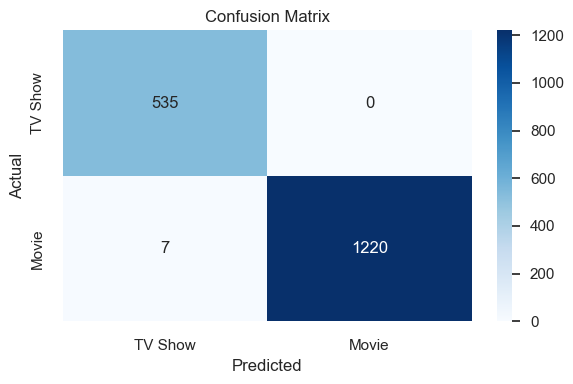

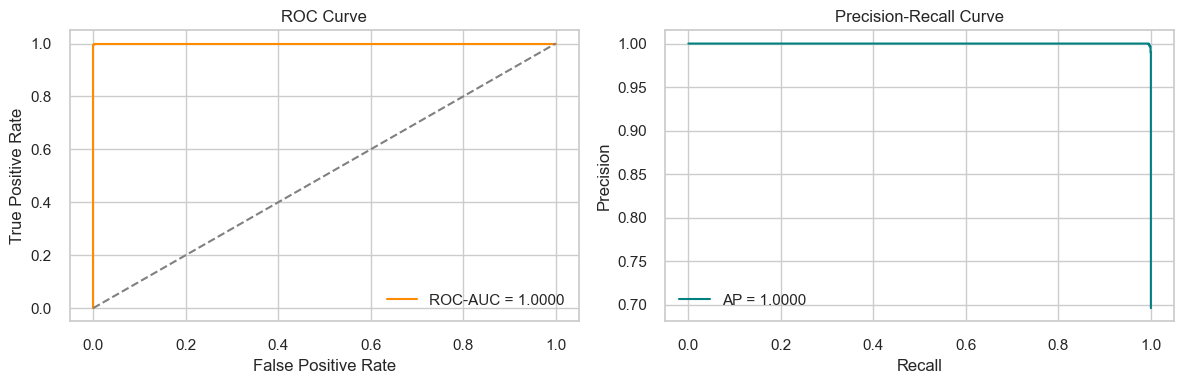

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["TV Show", "Movie"], yticklabels=["TV Show", "Movie"] )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}", color="darkorange")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="teal", label=f"AP = {avg_precision:.4f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

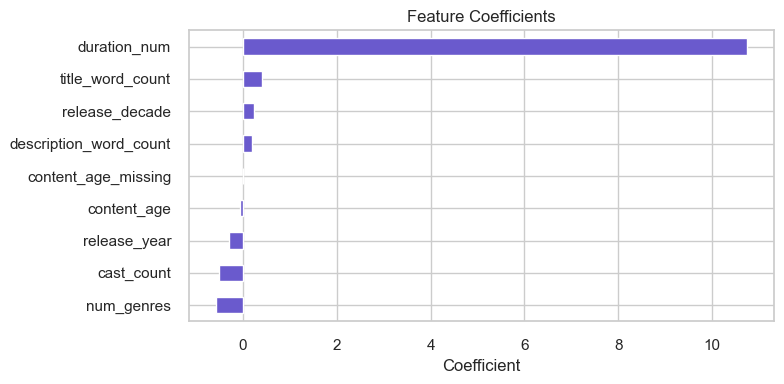

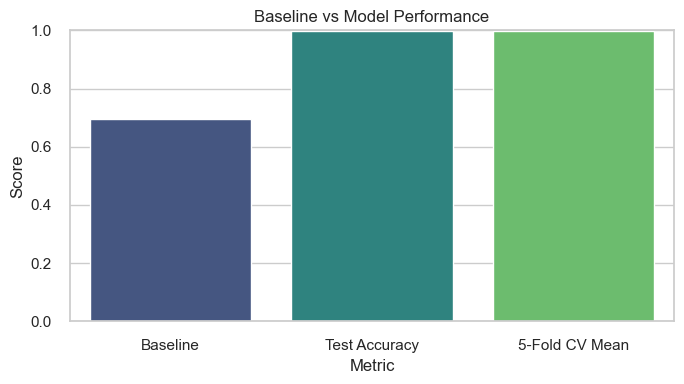

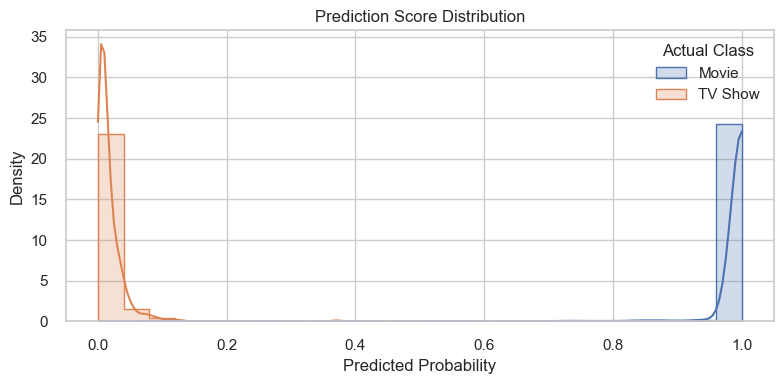


Top features by influence:
         Feature  Absolute Coefficient
    duration_num             10.756336
      num_genres              0.575721
      cast_count              0.509049
title_word_count              0.409895
    release_year              0.292324


In [30]:
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 4))
coefficients.plot(kind="barh", color="slateblue")
plt.title("Feature Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {
        "Metric": ["Baseline", "Test Accuracy", "5-Fold CV Mean"],
        "Score": [baseline_acc, accuracy, cv_scores.mean()],
    }
)
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="Metric", y="Score", palette="viridis")
plt.ylim(0, 1)
plt.title("Baseline vs Model Performance")
plt.tight_layout()
plt.show()

score_frame = pd.DataFrame(
    {
        "Predicted Probability": y_prob,
        "Actual Class": y_test.map({0: "TV Show", 1: "Movie"}).values,
    }
)
plt.figure(figsize=(8, 4))
sns.histplot(
    data=score_frame,
    x="Predicted Probability",
    hue="Actual Class",
    bins=25,
    stat="density",
    common_norm=False,
    element="step",
    kde=True,
)
plt.title("Prediction Score Distribution")
plt.tight_layout()
plt.show()

feature_summary = pd.DataFrame(
    {
        "Feature": X.columns,
        "Absolute Coefficient": np.abs(model.coef_[0]),
    }
).sort_values("Absolute Coefficient", ascending=False)
print("\nTop features by influence:")
print(feature_summary.head(5).to_string(index=False))

## 5. Resume Summary and Closing

In [31]:
print("Resume-ready summary:")
print(f"- Built a compact logistic regression model that achieved {accuracy*100:.2f}% test accuracy.")
print(f"- Validated performance with balanced accuracy ({balanced_acc:.4f}), ROC-AUC ({roc_auc:.4f}), and 5-fold CV ({cv_scores.mean():.4f} +/- {cv_scores.std():.4f}).")
print(f"- Ranked {len(X.columns)} engineered features to explain content-type prediction.")

conn.close()
print("Database connection closed")

Resume-ready summary:
- Built a compact logistic regression model that achieved 99.60% test accuracy.
- Validated performance with balanced accuracy (0.9971), ROC-AUC (1.0000), and 5-fold CV (0.9969 +/- 0.0013).
- Ranked 9 engineered features to explain content-type prediction.
Database connection closed
